# Idea
load tcsv model(s) and test them

In [1]:
import os
# os.nice(19)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path
from utils.data_loader import find_repo_root
from utils.modeling import aggregate_multistep_predictions
import joblib
import re

# Settings

In [2]:
sampling_rate = '5min'  # available: '20s', '1min', '5min'
start_time = '2024-07-24 00:00:00'
end_time = '2024-12-31 12:59:00'
columns =['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
target = 'trend'
m = 15

# Load Data

In [3]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns)
# filter by time range
GFOC_data = GFOC_data.loc[start_time:end_time]
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))

X_file = DATA_DIR / Path(f"X_{sampling_rate}.parquet")
X_test = pd.read_parquet(X_file)
X_test = X_test.loc[start_time:end_time]
y_file = DATA_DIR / Path(f"y_{target}_{sampling_rate}.parquet")
y_test = pd.read_parquet(y_file)
y_test = y_test.loc[start_time:end_time]
print(f"✅ Successfully loaded features X_test with shape: {X_test.shape} and target y_test with shape: {y_test.shape}")

✅ Successfully loaded data with shape: (46236, 4)
Column names in the dataset:
['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
Sample rate: 5min
✅ Successfully loaded features X_test with shape: (46224, 538) and target y_test with shape: (46224, 48)


# Load Models

In [11]:
from pathlib import Path
import re
import joblib

MODEL_DIR = find_repo_root() / Path("Analysis/modeling/tscv_models")

pipelines = {}

# pattern:
# tscv_MultiTaskLasso_{target}_pipeline_{alpha}_{number}.pkl
pattern = re.compile(
    r'tscv_MultiTaskLasso_'
    r'(?P<target>.+?)_pipeline_'
    r'(?P<alpha>\d+p\d+)_'
    r'(?P<number>[A-Za-z0-9]+)\.pkl'
)

# --- collect and sort files deterministically ---
pkl_files = []

for pkl_file in MODEL_DIR.glob("*.pkl"):
    match = pattern.match(pkl_file.name)
    if not match:
        continue

    target = match.group("target")
    alpha = float(match.group("alpha").replace("p", "."))
    number = match.group("number")  # string, e.g. "1", "1i"

    pkl_files.append((target, number, alpha, pkl_file))

# sort by target, number, alpha
pkl_files.sort(key=lambda x: (x[0], x[1], x[2]))

# --- load pipelines ---
for target, number, alpha, pkl_file in pkl_files:
    pipelines.setdefault(target, {}).setdefault(number, {})[alpha] = (
        joblib.load(pkl_file)
    )

print(f"✅ Successfully loaded pipelines for targets: {list(pipelines.keys())}")

✅ Successfully loaded pipelines for targets: ['trend']


Show all loaded pipelines

In [12]:
for target in pipelines.keys():
    print(f"Target: {target}")
    for number in pipelines[target].keys():
        alphas = list(pipelines[target][number].keys())
        print(f"  Number: {number}, Alphas: {alphas}")

Target: trend
  Number: 1, Alphas: [0.1, 0.25, 0.5, 1.0, 2.0, 5.0]
  Number: 3, Alphas: [1.0, 5.0]


# Subsets

In [13]:
Subset = True  # if True, train only on interesting subsets
if Subset:
    invert = False  # if True, train on the uninteresting times
    Subset_DIR = find_repo_root() / Path("Analysis/Subsets")
    Subset_name = 'subsets_eflag_meanstd.csv'  # 'subsets_Kp.csv'  # 'subsets_eflag.csv'  # 'subsets_meanstd.csv' # 'subsets_merged.csv'
    Subset_file = Subset_DIR / Path(Subset_name)

Create Mask

In [14]:
if Subset:
    intervals_df = pd.read_csv(Subset_file)
    df = GFOC_data.copy()
    mask = pd.Series(False, index=df.index)

    for _, row in intervals_df.iterrows():
        mask |= (df.index >= row["start"]) & (df.index <= row["end"])
    
    if invert:
        mask = ~mask

    # Test only on these times
    active_test = GFOC_data[mask].index.intersection(X_test.index)
    active_mask = X_test.index.isin(active_test)
    print(f"Testing on {len(active_test)} samples of total {X_test.shape[0]} samples")
else:
    # Train on all times
    print(f"Using all testing samples: {X_test.shape[0]}")
    active_mask = np.ones(X_test.shape[0], dtype=bool)

Testing on 31137 samples of total 46224 samples


# Run Pipelines

In [15]:
predictions = {}

for target in pipelines.keys():
    for number in pipelines[target].keys():
        for alpha, pipeline in pipelines[target][number].items():
            # predict
            y_test_pred = pd.DataFrame(
                pipeline.predict(X_test[active_mask]),
                index=X_test.index[active_mask],
                columns=y_test.columns
            )

            # store
            predictions.setdefault(target, {}) \
                       .setdefault(number, {})[alpha] = y_test_pred

# Check Coefficients

In [ ]:
# check active coefficients for each pipeline
for target in pipelines.keys():
    for number in pipelines[target].keys():
        for alpha, pipeline in pipelines[target][number].items():
            coefs = pipeline.named_steps['lasso'].coef_
            active_coefs = np.sum(np.any(coefs != 0, axis=0))
            total_coefs = coefs.shape[1]
            print(f"{target} {number}, Alpha: {alpha:.2f} => Active Coefficients: {active_coefs:3d}/{total_coefs} ({(active_coefs/total_coefs)*100:.2f}%)")

trend 1, Alpha: 0.10 => Active Coefficients: 359/538 (66.73%)
trend 1, Alpha: 0.25 => Active Coefficients: 315/538 (58.55%)
trend 1, Alpha: 0.50 => Active Coefficients: 272/538 (50.56%)
trend 1, Alpha: 1.00 => Active Coefficients: 207/538 (38.48%)
trend 1, Alpha: 2.00 => Active Coefficients: 164/538 (30.48%)
trend 1, Alpha: 5.00 => Active Coefficients:  99/538 (18.40%)
trend 3, Alpha: 1.00 => Active Coefficients: 174/538 (32.34%)
trend 3, Alpha: 5.00 => Active Coefficients:  88/538 (16.36%)



--trend | 1--
Common Active Coefficients (93):
lag_config_trend: 7 different features
    "Bz GSE": 47 lags,
    "|avg B|": 33 lags,
    "F10.7 (LASP)": 6 lags,
    "Temperature (K)": 4 lags,
    "Flow Speed (km/s": 1 lags,
    "median_decay_last_7D": 1 lags,
    "median_decay_last_30D": 1 lags,
['|avg B|_lag_1', '|avg B|_lag_3', '|avg B|_lag_4', '|avg B|_lag_5', '|avg B|_lag_6', '|avg B|_lag_12', '|avg B|_lag_13', '|avg B|_lag_14', '|avg B|_lag_15', '|avg B|_lag_16', '|avg B|_lag_17', '|avg B|_lag_18', '|avg B|_lag_19', '|avg B|_lag_20', '|avg B|_lag_21', '|avg B|_lag_23', '|avg B|_lag_24', '|avg B|_lag_26', '|avg B|_lag_27', '|avg B|_lag_28', '|avg B|_lag_29', '|avg B|_lag_31', '|avg B|_lag_32', '|avg B|_lag_33', '|avg B|_lag_34', '|avg B|_lag_35', '|avg B|_lag_36', '|avg B|_lag_42', '|avg B|_lag_54', '|avg B|_lag_60', '|avg B|_lag_66', '|avg B|_lag_72', '|avg B|_lag_78', 'Bz GSE_lag_1', 'Bz GSE_lag_3', 'Bz GSE_lag_4', 'Bz GSE_lag_5', 'Bz GSE_lag_6', 'Bz GSE_lag_7', 'Bz GSE_lag_8', 

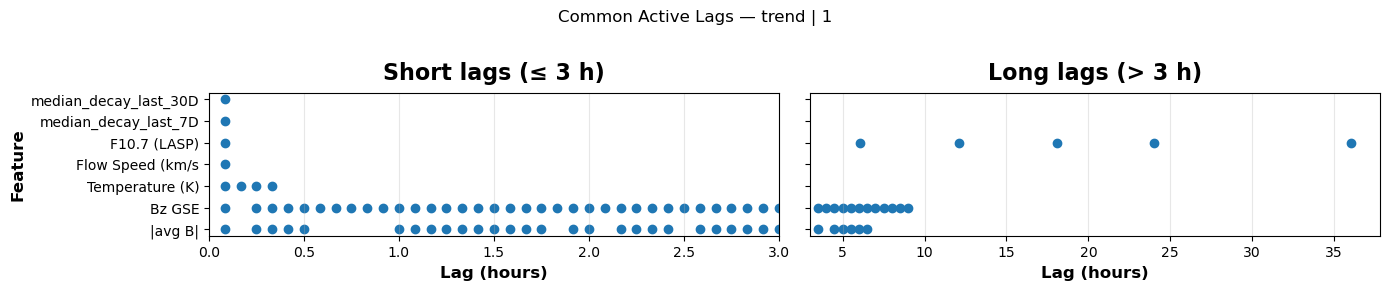


--trend | 3--
Common Active Coefficients (86):
lag_config_trend: 6 different features
    "Bz GSE": 43 lags,
    "|avg B|": 35 lags,
    "F10.7 (LASP)": 5 lags,
    "Flow Speed (km/s": 1 lags,
    "median_decay_last_7D": 1 lags,
    "median_decay_last_30D": 1 lags,
['|avg B|_lag_1', '|avg B|_lag_2', '|avg B|_lag_3', '|avg B|_lag_4', '|avg B|_lag_5', '|avg B|_lag_6', '|avg B|_lag_7', '|avg B|_lag_10', '|avg B|_lag_11', '|avg B|_lag_12', '|avg B|_lag_13', '|avg B|_lag_14', '|avg B|_lag_15', '|avg B|_lag_16', '|avg B|_lag_17', '|avg B|_lag_18', '|avg B|_lag_19', '|avg B|_lag_20', '|avg B|_lag_21', '|avg B|_lag_22', '|avg B|_lag_23', '|avg B|_lag_24', '|avg B|_lag_25', '|avg B|_lag_26', '|avg B|_lag_27', '|avg B|_lag_28', '|avg B|_lag_29', '|avg B|_lag_30', '|avg B|_lag_31', '|avg B|_lag_32', '|avg B|_lag_33', '|avg B|_lag_34', '|avg B|_lag_35', '|avg B|_lag_36', '|avg B|_lag_42', 'Bz GSE_lag_1', 'Bz GSE_lag_3', 'Bz GSE_lag_4', 'Bz GSE_lag_5', 'Bz GSE_lag_6', 'Bz GSE_lag_7', 'Bz GSE_lag_8

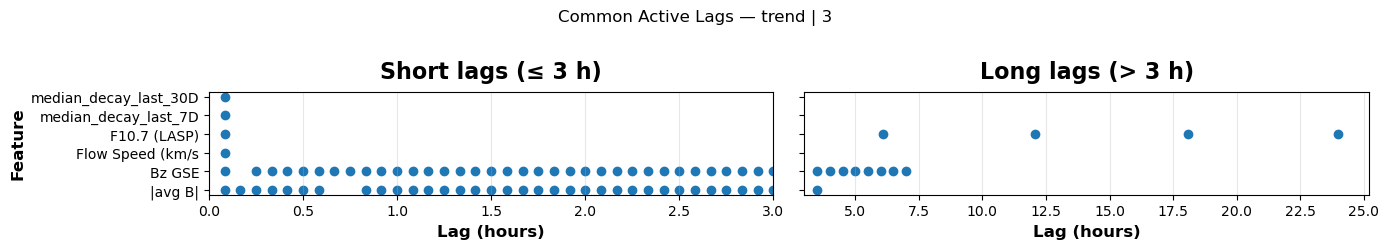

In [40]:
# find coefficients that appear in every pipeline per number
for target in pipelines.keys():
    for number in pipelines[target].keys():
        coefs_names = X_test.columns
        common_active_coefs = None

        for alpha, pipeline in pipelines[target][number].items():
            coefs = pipeline.named_steps['lasso'].coef_
            active_coefs = np.any(coefs != 0, axis=0)

            if common_active_coefs is None:
                common_active_coefs = active_coefs
            else:
                common_active_coefs &= active_coefs

        # print list of common active coefficients
        common_coef_names = coefs_names[common_active_coefs]
        print(f"\n--{target} | {number}--\nCommon Active Coefficients ({len(common_coef_names)}):")
        features = common_coef_names.str.extract(r'^(.+?)_lag_')[0]
        summary = (
            features
            .value_counts()
            .rename_axis('feature')
            .reset_index(name='n_columns')
        )
        print(f"lag_config_trend: {len(summary)} different features")
        for feature, k in summary.itertuples(index=False):
            print(f'    "{feature}": {k} lags,')
        print(list(common_coef_names))

        df_plot = (
            common_coef_names
            .to_series(name="coef")
            .str.extract(r'^(?P<feature>.+?)_lag_(?P<lag>\d+)$')
            .assign(lag=lambda d: d["lag"].astype(int))
        )
        feature_order = df_plot["feature"].unique()
        feature_to_y = {f: i for i, f in enumerate(feature_order)}

        y = df_plot["feature"].map(feature_to_y)
        # one lag step is 5 minutes
        df_plot["hours"] = df_plot["lag"] * 5 / 60  # hours

        # two panel plot
        h_split = 3  # hours

        mask_short = df_plot["hours"] <= h_split
        mask_long  = df_plot["hours"] > h_split

        fig, (ax1, ax2) = plt.subplots(
            1, 2,
            sharey=True,
            figsize=(14, 0.4 * len(feature_order)),
            gridspec_kw={"width_ratios": [1, 1]}
        )

        # --- Left panel: short lags ---
        ax1.scatter(
            df_plot.loc[mask_short, "hours"],
            y[mask_short]
        )
        ax1.set_xlim(0, h_split)
        ax1.set_xlabel("Lag (hours)")
        ax1.set_title("Short lags (≤ 3 h)")
        ax1.grid(axis="x", alpha=0.3)

        # --- Right panel: long lags ---
        ax2.scatter(
            df_plot.loc[mask_long, "hours"],
            y[mask_long]
        )
        ax2.set_xlim(h_split, df_plot["hours"].max() * 1.05)
        ax2.set_xlabel("Lag (hours)")
        ax2.set_title("Long lags (> 3 h)")
        ax2.grid(axis="x", alpha=0.3)

        # --- Y axis ---
        ax1.set_yticks(range(len(feature_order)))
        ax1.set_yticklabels(feature_order)
        ax1.set_ylabel("Feature")

        # --- Overall title ---
        fig.suptitle(f"Common Active Lags — {target} | {number}", y=1.02)

        plt.tight_layout()
        plt.show()


